# 03 — Нэгдсэн LightGBM модель (`has_hur`/`has_zms` flag + Optuna HPO)

**Шинэчлэл.** Өмнө нь сегмент бүрд тусдаа модель сургадаг байсныг больж, **бүх
популяци дээр НЭГ нэгдсэн LightGBM** сургана. Сегментийн ялгааг тусдаа модельгүйгээр
**`has_hur`, `has_zms` flag**-аар модельд "хэлж" өгнө. Ингэснээр:

- `hur_only` (зөвхөн 106) гэх жижиг бүлгийг ч **сургалтад бүрэн оролцуулна** —
  тусдаа модель сургах хэрэггүй (хэт цөөн дата дээр overfit болохгүй).
- Бүх бүлэг нэг модельд хамт сурснаар хоорондын ерөнхий хэв шинжийг хуваалцана,
  flag нь хэзээ цалин/бюро мэдээлэл байхгүйг модельд мэдэгдэнэ.

**Аргууд:** Optuna HPO, city target encoding (leakage-гүй), `class_weight='balanced'`.

> `N_TRIALS`, `N_SPLITS` нь хурдны үүднээс багасгасан — локал дээр нэмэгдүүл.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE

import config, features, metrics

plt.rcParams['figure.dpi'] = 120
os.makedirs(config.MODEL_DIR, exist_ok=True)

TARGET = config.PRIMARY_TARGET   # '30'
SEED = config.SEED

df = config.load_data()
df = features.engineer_features(df)
df['segment'] = df.apply(config.assign_segment, axis=1)
print(f"Loaded: {df.shape}")
print(df['segment'].value_counts())

[load_data] neither хасав: 57,127 → 39,242 (17,885 мөр хасагдсан)


Loaded: (39242, 108)
segment
both        27549
zms_only    11587
hur_only      106
Name: count, dtype: int64


## 1. Feature набор + хувьсагч сонголт (IV + корреляц)

Бүх numeric feature (+ `has_hur`/`has_zms` flag) дотроос **IV ≥ 0.02** ба
**|r| ≤ 0.75** болгож цөөлнө (ЗӨВХӨН train дээр). Цөөлсөн олонлогоор модель сургана.
Heatmap нь multicollinearity цөөлөхөөс өмнө/хойш хэрхэн буурсныг харуулна.

Бүх numeric: 100  →  IV+корреляц шүүлтийн дараа: 43
has_hur сонгогдсон: False  | has_zms: False


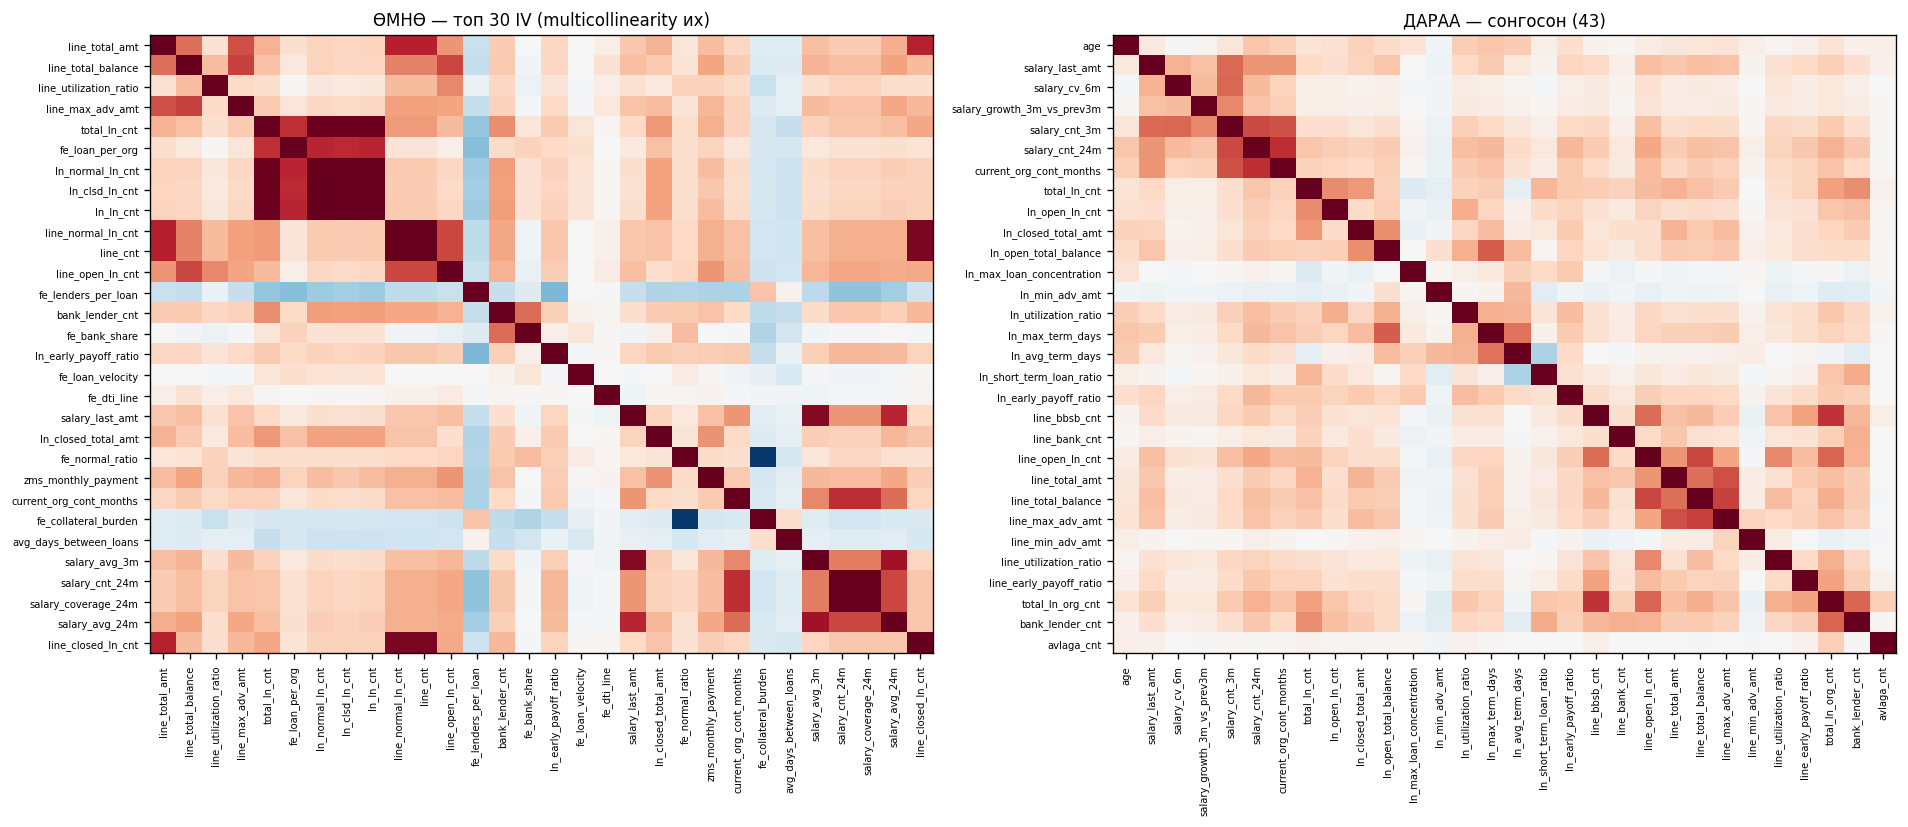

In [2]:
import feature_selection as fs
import pandas as pd

ALL_FEATS = config.feature_columns(df)
EXCLUDE = {'segment', 'is_test', 'city_name', 'region'}
num_all = [c for c in ALL_FEATS if c not in EXCLUDE and df[c].dtype.kind in 'fi']

IS_TEST = config.make_split(df)
df_tr = df[~IS_TEST]
NUM_FEATS, iv = fs.select_features(df_tr, num_all, TARGET, categorical=(),
                                  iv_threshold=0.02, corr_threshold=0.75)
print(f"Бүх numeric: {len(num_all)}  →  IV+корреляц шүүлтийн дараа: {len(NUM_FEATS)}")
print(f"has_hur сонгогдсон: {'has_hur' in NUM_FEATS}  | has_zms: {'has_zms' in NUM_FEATS}")

iv_s = pd.Series(iv).sort_values(ascending=False)
before = [c for c in iv_s.head(30).index if c in df_tr.columns]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
metrics.plot_corr_heatmap(df_tr, before, axes[0], 'ӨМНӨ — топ 30 IV (multicollinearity их)')
metrics.plot_corr_heatmap(df_tr, NUM_FEATS[:30], axes[1], f'ДАРАА — сонгосон ({len(NUM_FEATS)})')
plt.tight_layout(); plt.show()

### Сонгогдсон хувьсагчийн жагсаалт (IV-тэй)

Цөөлж сонгосон хувьсагч бүрийг IV (ялгах чадвар), хүч, төрлөөр нь харуулна.

In [3]:
sel_tbl = pd.DataFrame({'feature': list(NUM_FEATS)})
sel_tbl['IV'] = sel_tbl['feature'].map(lambda c: round(iv.get(c, float('nan')), 3))
sel_tbl['хүч'] = sel_tbl['IV'].map(lambda v: fs.iv_label(v) if v == v else '— (категори)')
sel_tbl['төрөл'] = sel_tbl['feature'].map(
    lambda c: 'flag' if c in ('has_hur', 'has_zms')
    else ('категори' if c in config.CATEGORICAL_VARS
          else ('fe (шинэ)' if c.startswith('fe_') else 'түүхий')))
sel_tbl = sel_tbl.sort_values('IV', ascending=False, na_position='last').reset_index(drop=True)
sel_tbl.index = sel_tbl.index + 1
print(f"СОНГОГДСОН {len(sel_tbl)} ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):")
print(sel_tbl.to_string())

СОНГОГДСОН 43 ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):
                       feature     IV     хүч      төрөл
1               line_total_amt  0.153  Medium     түүхий
2           line_total_balance  0.145  Medium     түүхий
3       line_utilization_ratio  0.140  Medium     түүхий
4             line_max_adv_amt  0.135  Medium     түүхий
5                 total_ln_cnt  0.132  Medium     түүхий
6              fe_loan_per_org  0.121  Medium  fe (шинэ)
7             line_open_ln_cnt  0.103  Medium     түүхий
8          fe_lenders_per_loan  0.087    Weak  fe (шинэ)
9              bank_lender_cnt  0.087    Weak     түүхий
10       ln_early_payoff_ratio  0.086    Weak     түүхий
11               fe_bank_share  0.086    Weak  fe (шинэ)
12            fe_loan_velocity  0.085    Weak  fe (шинэ)
13             salary_last_amt  0.084    Weak     түүхий
14                 fe_dti_line  0.084    Weak  fe (шинэ)
15         ln_closed_total_amt  0.083    Weak     түүхий
16             fe_normal_ratio  0.080    Wea

## 2. Zone encoding (city_name-ийн оронд)

High-cardinality `city_name` (75 анги)-г **`zone` (14 анги)** болгож, хоёр аргаар тоон болгоно: (1) **target encoding** (train дээр fit, нэг багана), (2) **one-hot** (14 багана). Доор хоёуланг харьцуулна. Гол модель нь target encoding ашиглана (`zone_te`).

In [4]:
def target_encode(train_series, train_target, test_series, smoothing=10):
    global_mean = train_target.mean()
    stats = pd.DataFrame({'k': train_series.values, 'y': train_target}) \
              .groupby('k')['y'].agg(['mean','count'])
    smoothed = (stats['mean']*stats['count'] + global_mean*smoothing) \
               / (stats['count']+smoothing)
    tr = train_series.map(smoothed).fillna(global_mean)
    te = test_series.map(smoothed).fillna(global_mean)
    return tr.values, te.values, smoothed, global_mean

## 3. Optuna HPO + нэгдсэн LightGBM (бүх популяци)

Нэг модель бүх популяци дээр. Optuna нь `N_TRIALS` удаа гиперпараметр туршиж
`N_SPLITS`-fold CV-ээр AUC үнэлнэ. Хамгийн сайн параметрээр эцсийн модель сургаж,
нийтлэг test дээр үнэлнэ. `class_weight='balanced'` нь тэнцвэргүй байдлыг зохицуулна.

In [5]:
N_TRIALS = 6           # хурдавчилсан — локал дээр 30+ болго
N_SPLITS = 2           # CV fold — локал дээр 4-5 болго

IS_TEST = config.make_split(df)        # нийтлэг хуваалт
df = df.copy()
df['is_test'] = IS_TEST

X_all = df[NUM_FEATS].copy().fillna(-999)
y_all = df[TARGET].values
zone_all = df['zone'].astype(str)
tr_mask = ~df['is_test'].values
Xtr, Xte = X_all[tr_mask], X_all[~tr_mask]
ytr, yte = y_all[tr_mask], y_all[~tr_mask]
zone_tr = zone_all[tr_mask]; zone_te = zone_all[~tr_mask]
print(f"Train: {len(Xtr):,}  Test: {len(Xte):,}")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 350),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 48),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 40, 200),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    Xr = Xtr.reset_index(drop=True); zr = zone_tr.reset_index(drop=True)
    aucs = []
    for tri, vai in skf.split(Xr, ytr):
        X_t, X_v = Xr.iloc[tri].copy(), Xr.iloc[vai].copy()
        y_t, y_v = ytr[tri], ytr[vai]
        zte_t, zte_v, _, _ = target_encode(zr.iloc[tri], y_t, zr.iloc[vai])
        X_t['zone_te'] = zte_t; X_v['zone_te'] = zte_v
        m = LGBMClassifier(**params, class_weight='balanced',
                           random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X_t, y_t)
        aucs.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
    return np.mean(aucs)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"Best CV AUC: {study.best_value:.4f}")

# Гол модель: target-encoded zone
zte_tr, zte_te, zone_map, gmean = target_encode(zone_tr, ytr, zone_te)
X_tr = Xtr.copy(); X_tr['zone_te'] = zte_tr
X_te = Xte.copy(); X_te['zone_te'] = zte_te
FEATS = list(X_tr.columns)
model = LGBMClassifier(**study.best_params, class_weight='balanced',
                       random_state=SEED, n_jobs=-1, verbose=-1)
model.fit(X_tr, ytr)
p_te = model.predict_proba(X_te)[:, 1]
m = metrics.eval_metrics(yte, p_te, 'Combined test (zone target-enc)')
joblib.dump({'model': model, 'feats': FEATS, 'zone_map': zone_map,
             'gmean': gmean, 'metrics': m, 'best_params': study.best_params},
            os.path.join(config.MODEL_DIR, 'lgbm_combined_30.joblib'))

Train: 31,393  Test: 7,849


Best CV AUC: 0.6801


Combined test (zone target-enc)  AUC=0.6861  Gini=0.3723  KS=0.2831


['../models/lgbm_combined_30.joblib']

### Encoding харьцуулалт: target encoding vs one-hot

Ижил гиперпараметр (`study.best_params`) дээр zone-г хоёр аргаар кодлож, TEST AUC-г харьцуулна. 14 анги цөөн тул хоёр арга ойролцоо гарах нь ердийн.

In [6]:
import pandas as pd
# (A) target encoding — аль хэдийн дээр сурсан model (zone_te)
auc_te = metrics.roc_auc_score(yte, p_te)

# (B) one-hot zone (14 багана)
oh_tr = pd.get_dummies(zone_tr, prefix='zone')
oh_te = pd.get_dummies(zone_te, prefix='zone').reindex(columns=oh_tr.columns, fill_value=0)
Xtr_oh = pd.concat([Xtr.reset_index(drop=True), oh_tr.reset_index(drop=True)], axis=1)
Xte_oh = pd.concat([Xte.reset_index(drop=True), oh_te.reset_index(drop=True)], axis=1)
model_oh = LGBMClassifier(**study.best_params, class_weight='balanced',
                          random_state=SEED, n_jobs=-1, verbose=-1)
model_oh.fit(Xtr_oh, ytr)
auc_oh = metrics.roc_auc_score(yte, model_oh.predict_proba(Xte_oh)[:, 1])

cmp = pd.DataFrame({
    'Encoding': ['Target encoding (zone_te)', f'One-hot ({oh_tr.shape[1]} багана)'],
    'Test AUC': [round(auc_te, 4), round(auc_oh, 4)],
    'Test Gini': [round(2*auc_te-1, 4), round(2*auc_oh-1, 4)],
})
print(cmp.to_string(index=False))
print(f"\nШилдэг: {'Target encoding' if auc_te>=auc_oh else 'One-hot'}")

                 Encoding  Test AUC  Test Gini
Target encoding (zone_te)    0.6861     0.3723
      One-hot (14 багана)    0.6860     0.3720

Шилдэг: Target encoding


## 4. Бүх популяцийн оноо ба сегментээр задлах

Нэг модель бүх харилцагчид оноо өгнө. Дараа нь сегмент бүрээр (`both`,
`zms_only`, `hur_only`) test AUC-г задалж, flag-тэй нэг модель сегмент бүр дээр
хэрхэн ажиллаж байгааг шалгана.

In [7]:
from sklearn.metrics import roc_auc_score

df_score = df.copy()
Xs = df_score[NUM_FEATS].copy().fillna(-999)
Xs['zone_te'] = df_score['zone'].astype(str).map(zone_map).fillna(gmean).values
Xs = Xs[FEATS]
df_score['prob_bad'] = model.predict_proba(Xs)[:, 1]
df_score['score_350_850'] = (config.SCORE_MAX -
    df_score['prob_bad'] * (config.SCORE_MAX - config.SCORE_MIN)).clip(
    config.SCORE_MIN, config.SCORE_MAX)

te = df_score['is_test']
metrics.eval_metrics(df_score.loc[te, TARGET].values,
                     df_score.loc[te, 'prob_bad'].values, 'TEST (full population)')
print("\nСегментээр (зөвхөн test):")
for seg in ['both', 'zms_only', 'hur_only']:
    msk = (df_score['segment'] == seg) & te
    yv = df_score.loc[msk, TARGET]
    if msk.sum() > 0 and yv.nunique() > 1:
        a = roc_auc_score(yv, df_score.loc[msk, 'prob_bad'])
        print(f"  {seg:9s} test AUC={a:.4f}  (n={int(msk.sum())}, bad={int(yv.sum())})")
    else:
        print(f"  {seg:9s} test хэт цөөн (n={int(msk.sum())}, bad={int(yv.sum())})")
df_score[['segment', 'prob_bad', 'score_350_850']].head()

TEST (full population)          AUC=0.6861  Gini=0.3723  KS=0.2831

Сегментээр (зөвхөн test):
  both      test AUC=0.6810  (n=5498, bad=601)
  zms_only  test AUC=0.6590  (n=2320, bad=408)
  hur_only  test AUC=0.4483  (n=31, bad=2)


,segment,prob_bad,score_350_850
0,zms_only,0.698680,500.660110
1,zms_only,0.336789,681.605475
2,both,0.341910,679.045162
3,both,0.274005,712.997564
4,both,0.553168,573.416005


## 5. ROC — бүх сегмент

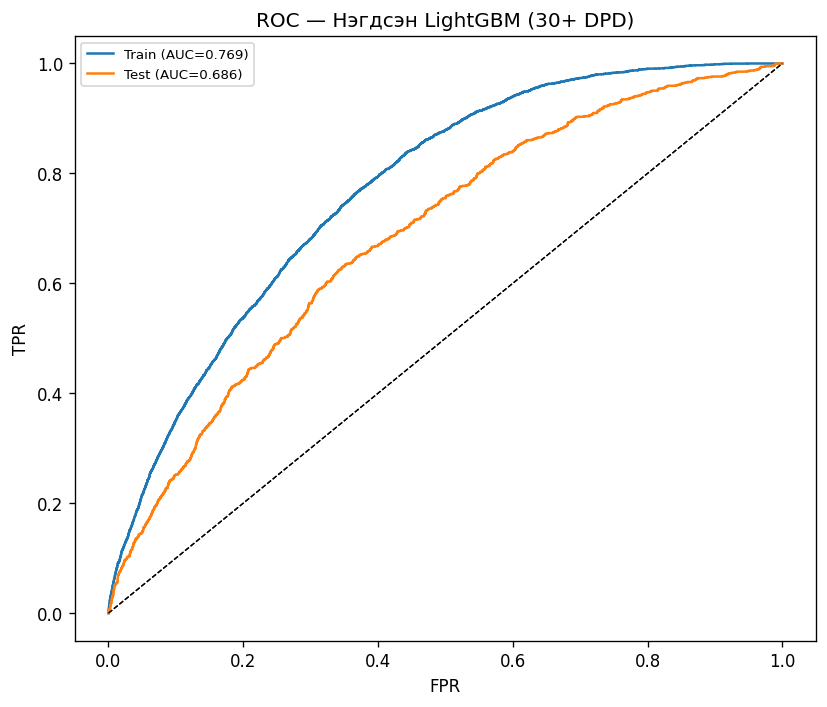

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
metrics.plot_roc(ytr, model.predict_proba(X_tr)[:, 1], 'Train', ax)
metrics.plot_roc(yte, p_te, 'Test', ax)
ax.set_title('ROC — Нэгдсэн LightGBM (30+ DPD)')
plt.tight_layout(); plt.show()

## 6. Score band хүснэгт

Оноог 5 зэрэгт хувааж зэрэг бүрийн bad rate-г харуулна — оноо буурах тусам bad rate өсөж байвал модель зөв ажиллаж байна.

In [9]:
band = metrics.score_band_table(
    df_score['score_350_850'].values, df_score[TARGET].values)
print(band.to_string(index=False))

                 Band  Count  Pct %  Bad Rate %
       Poor (350-450)     26   0.07       69.23
       Fair (450-550)   7325  18.67       29.39
       Good (550-650)  16932  43.15       14.25
  Very Good (650-750)  11387  29.02        3.87
Exceptional (750-850)   3572   9.10        0.90


## 8. Оноо × bad rate ба хувьсагч × bad rate

TEST дээр оноо буурах тусам bad rate өсөж байгаа эсэх, мөн сонгосон топ
хувьсагчдын bin тус бүрийн bad rate монотон эсэхийг харна.

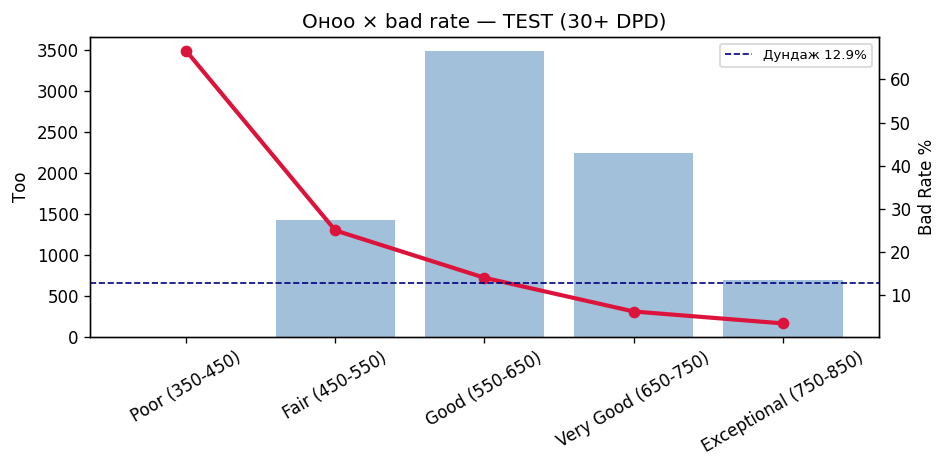

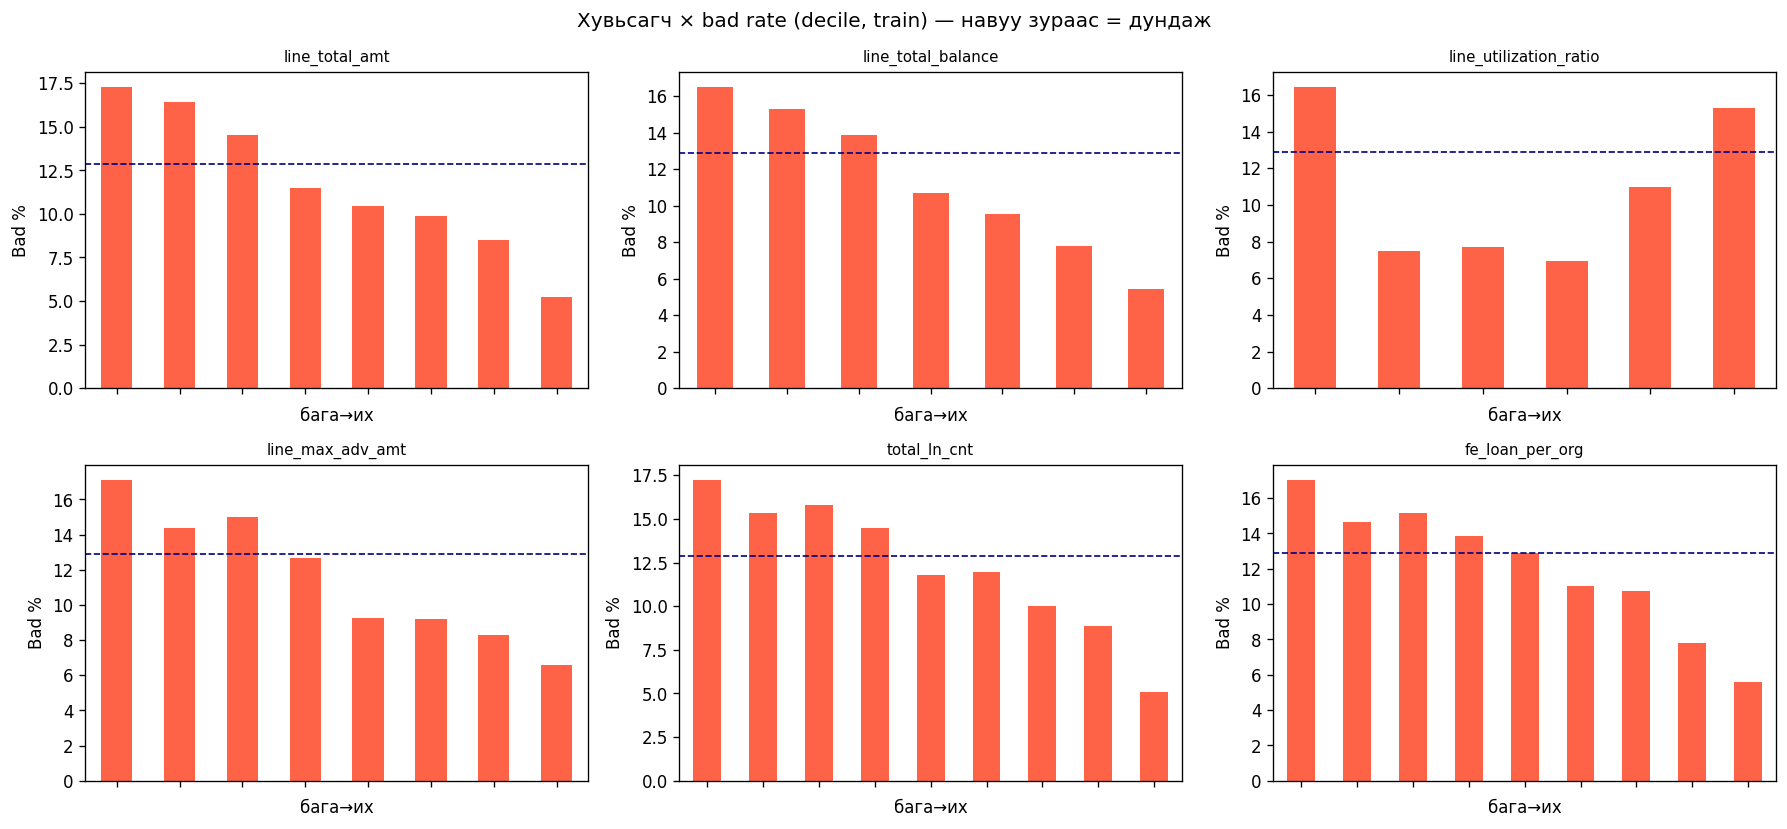

In [10]:
# (1) Оноо × bad rate — TEST
te = df_score['is_test']
fig, ax = plt.subplots(figsize=(8, 4))
metrics.plot_badrate_by_band(df_score.loc[te, 'score_350_850'].values,
                             df_score.loc[te, TARGET].values, ax=ax)
ax.set_title('Оноо × bad rate — TEST (30+ DPD)')
plt.tight_layout(); plt.show()

# (2) Хувьсагч × bad rate (сонгосон топ 6, train)
iv_sel = pd.Series({c: iv.get(c, 0) for c in NUM_FEATS}).sort_values(ascending=False)
top6 = list(iv_sel.head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), top6):
    metrics.plot_feature_badrate(df_tr, feat, TARGET, ax)
plt.suptitle('Хувьсагч × bad rate (decile, train) — навуу зураас = дундаж')
plt.tight_layout(); plt.show()

## 7. Feature importance (`has_hur`/`has_zms` flag-ийг онцолсон)

Улаан = сегмент flag. Flag өндөр байр эзэлбэл бүлгийн ялгаа таамаглалд чухал
гэсэн үг (нэг модель сегментийг сайн ялгаж байна).

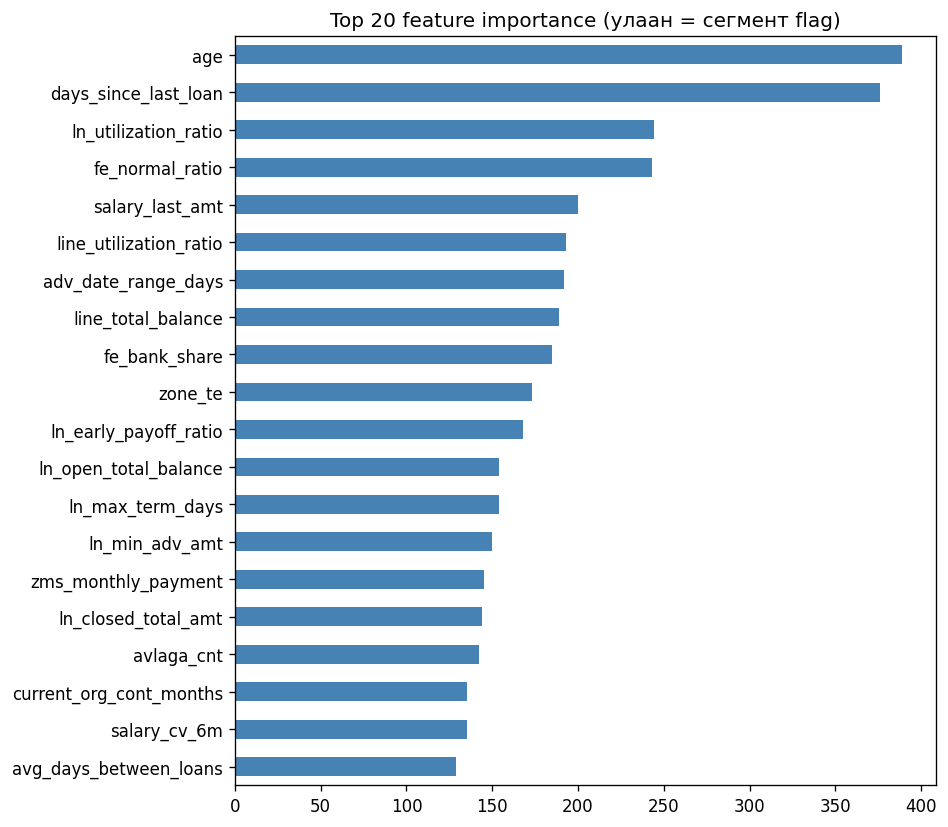

Flag-ийн байр:


In [11]:
names = model.booster_.feature_name()
imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)
top = imp.head(20)[::-1]
colors = ['crimson' if n in ('has_hur', 'has_zms') else 'steelblue' for n in top.index]
fig, ax = plt.subplots(figsize=(8, 7))
top.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 feature importance (улаан = сегмент flag)')
plt.tight_layout(); plt.show()
print('Flag-ийн байр:')
for fl in ['has_hur', 'has_zms']:
    if fl in imp.index:
        print(f"  {fl}: {list(imp.index).index(fl)+1}/{len(imp)}-р байр, importance={int(imp[fl])}")

## Дүгнэлт

- **Нэг нэгдсэн модель** бүх популяци дээр сурч, `has_hur`/`has_zms` flag-аар
  сегментийн ялгааг барина. `hur_only` (106) хүртэл сургалтад бүрэн оролцов.
- Сегментээр задалсан test AUC дээрх гаралтад харагдана — нэг модель бүх бүлэгт
  хүлээн зөвшөөрөгдөх түвшинд ажиллаж байгаа эсэхийг шалгана.
- **SMOTE-гүй, `class_weight='balanced'`** — магадлалын calibration илүү тогтвортой.
- **Хурд:** `N_TRIALS=6`, `N_SPLITS=2`. Локал дээр нэмэгдүүлбэл AUC сайжирна.
- **Дараагийн алхам:** out-of-time валидаци, calibration, PSI мониторинг.